# 08 — Learning curves

Load sweep results from `07_sample_size_sweep.ipynb` and produce
publication-quality figures:

1. **NLL learning curves** — train / val / gen NLL vs $N$ overlaid with
   the solution curves (uniform, unigram, empirical bigram, Bayes).
   The gap between gen NLL and Bayes NLL is the *excess generalisation loss*.

2. **Solution proximity** — KL distance from the model's learned $\hat T$ to
   each reference solution vs $N$, showing which the network has found.

3. **Transition matrix gallery** — $\hat T_N$ heatmaps at selected $N$ values,
   arranged left-to-right from small to large $N$.

4. **Per-epoch curves at selected $N$** — the within-run training dynamics
   for a few representative sample sizes.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt = cwd / "projects" / "markov-chain-learning"
    if (alt / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt
if project_root is None:
    raise RuntimeError("Could not locate project root")

DATA_DIR = project_root / "experiments" / "single-chain" / "data"
sweep_path = DATA_DIR / "sample_size_sweep.pt"

if not sweep_path.exists():
    raise FileNotFoundError(
        f"Run 07_sample_size_sweep.ipynb first.\nExpected: {sweep_path}"
    )

records = torch.load(sweep_path, weights_only=False)
print(f"Loaded {len(records)} sweep records  (N={[r['N'] for r in records]})")

Loaded 10 sweep records  (N=[50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000])


In [3]:
# ── Load reference values ─────────────────────────────────────────────────────
data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
data_cfg = data.get("config", {})
Ts, pis = data["Ts"], data["pis"]
VOCAB = int(data_cfg.get("n_states", Ts.shape[-1]))

if Ts.shape[0] == 1:
    T_reference = Ts[0]
    pi_reference = pis[0]
else:
    chain_weights = torch.bincount(
        data["chain_to_sample"], minlength=Ts.shape[0]
    ).float()
    chain_weights /= chain_weights.sum()
    T_reference = (chain_weights[:, None, None] * Ts).sum(0)
    pi_reference = (chain_weights[:, None] * pis).sum(0)

bayes_nll = records[0]["nll_bayes"]
uniform_nll = records[0]["nll_uniform"]

## 1 — NLL learning curves

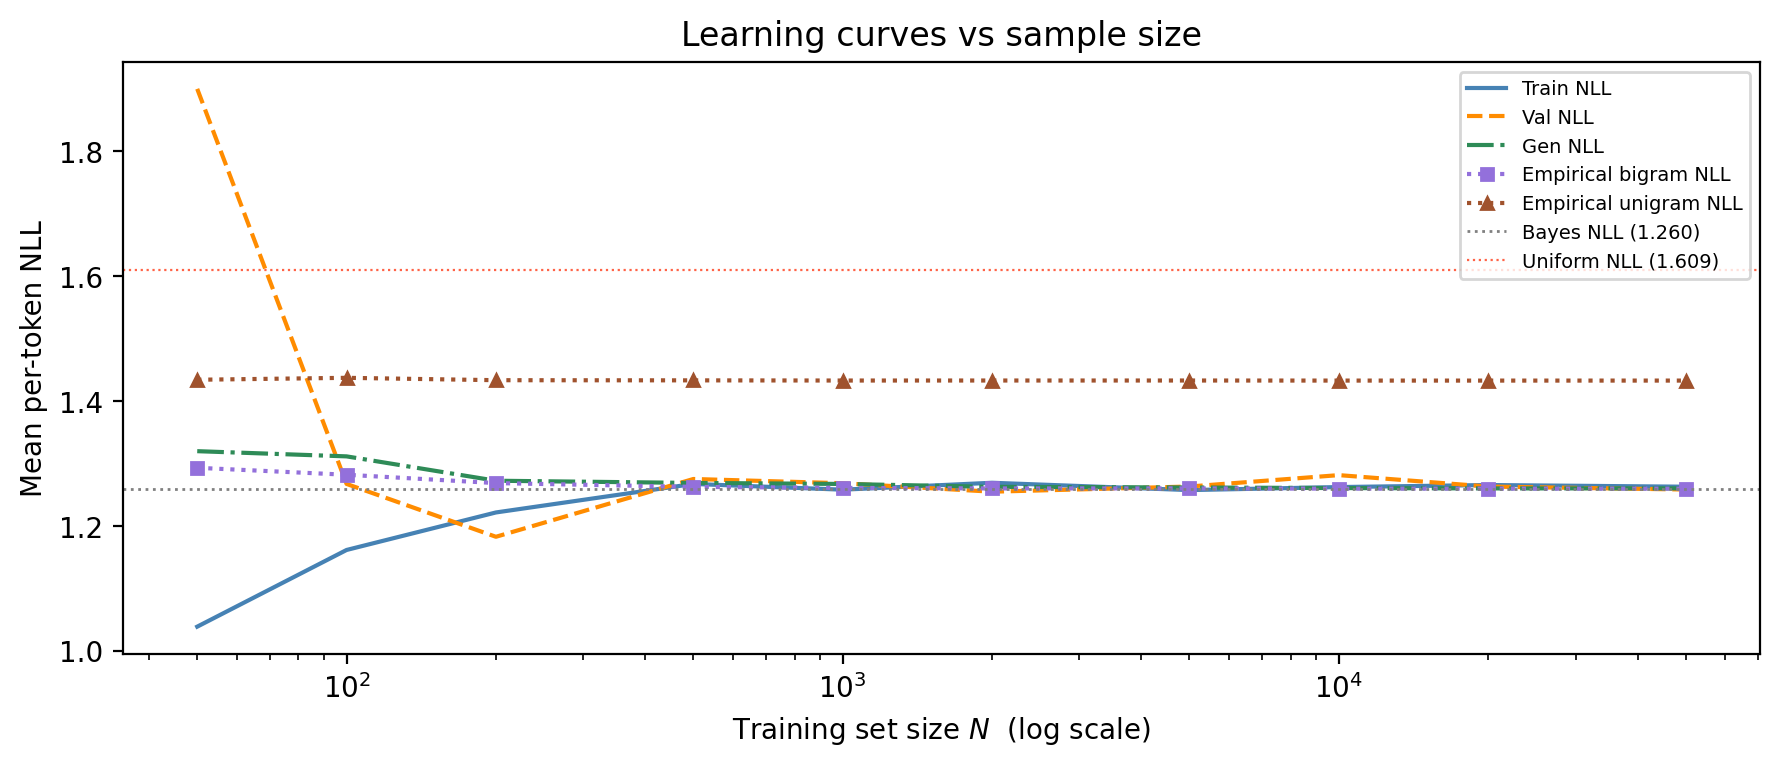

In [4]:
Ns = [r["N"] for r in records]
train_nlls = [r["train_nll"] for r in records]
val_nlls = [r["val_nll"] for r in records]
gen_nlls = [r["gen_nll"] for r in records]
bigram_nlls = [r["nll_bigram"] for r in records]
unigram_nlls = [r["nll_unigram"] for r in records]

fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogx(Ns, train_nlls, color="steelblue", label="Train NLL")
ax.semilogx(Ns, val_nlls, color="darkorange", linestyle="--", label="Val NLL")
ax.semilogx(Ns, gen_nlls, color="seagreen", linestyle="-.", label="Gen NLL")
ax.semilogx(
    Ns,
    bigram_nlls,
    color="mediumpurple",
    linestyle=":",
    label="Empirical bigram NLL",
    marker="s",
    markersize=4,
)
ax.semilogx(
    Ns,
    unigram_nlls,
    color="sienna",
    linestyle=":",
    label="Empirical unigram NLL",
    marker="^",
    markersize=4,
)
ax.axhline(
    bayes_nll,
    color="gray",
    linewidth=1.0,
    linestyle=":",
    label=f"Bayes NLL ({bayes_nll:.3f})",
)
ax.axhline(
    uniform_nll,
    color="tomato",
    linewidth=0.8,
    linestyle=":",
    label=f"Uniform NLL ({uniform_nll:.3f})",
)

ax.set_xlabel("Training set size $N$  (log scale)")
ax.set_ylabel("Mean per-token NLL")
ax.set_title("Learning curves vs sample size")
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

## 2 — Solution proximity (KL distances)

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/var/folders/_0/_rfflcbd5hv5zqzl2hnzrp6c0000gn/T/ipykernel_39911/1817950409.py:41: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel("KL divergence (weighted by $\pi$)")


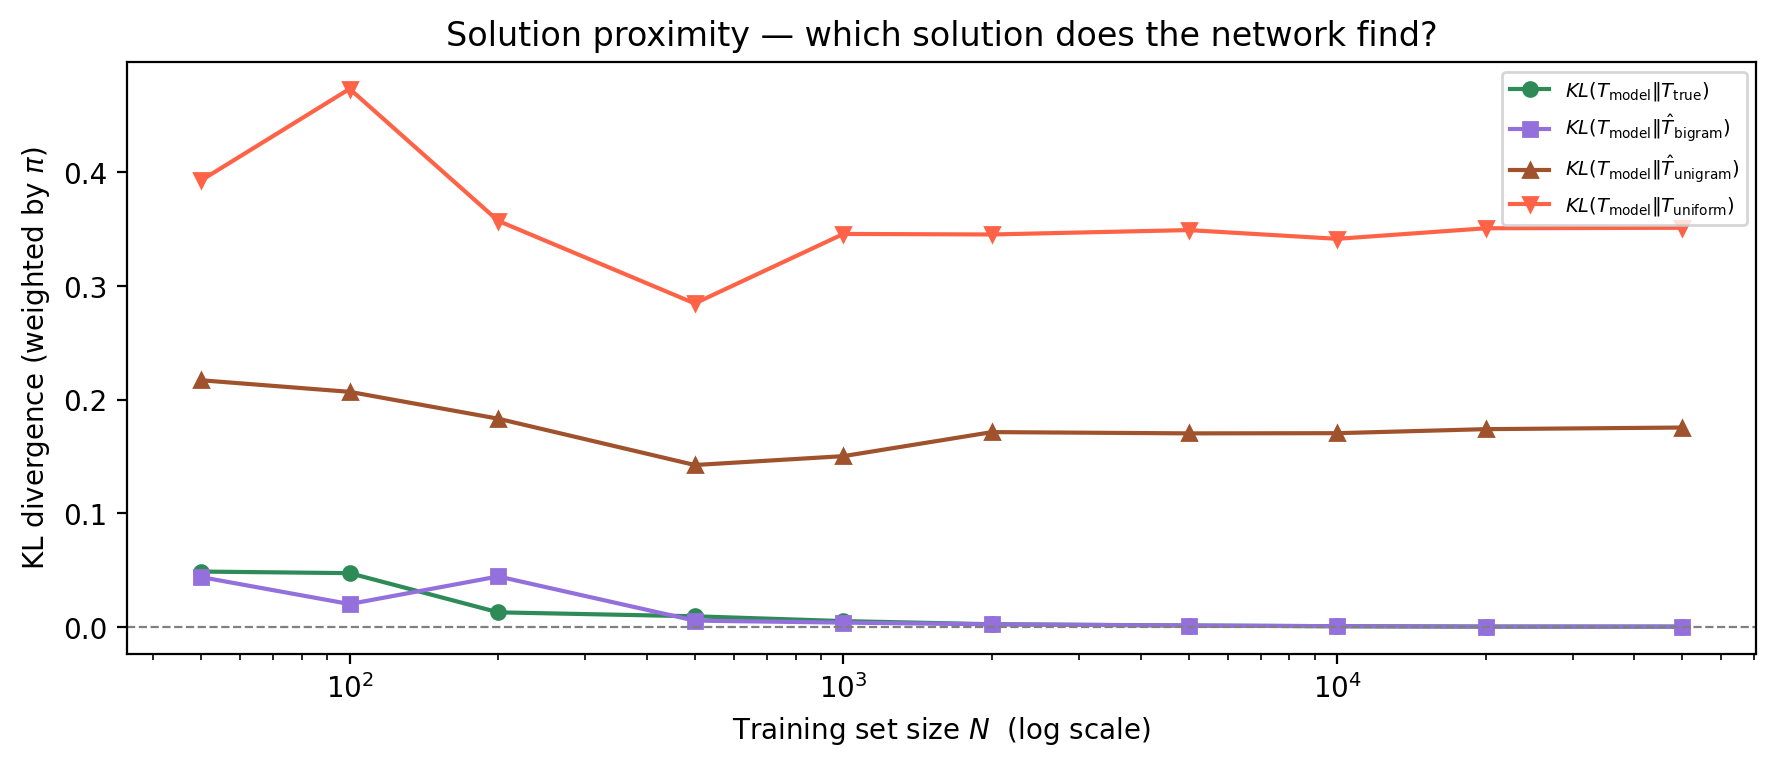

In [5]:
kl_true = [r["kl_to_true"] for r in records]
kl_bigram = [r["kl_to_bigram"] for r in records]
kl_unigram = [r["kl_to_unigram"] for r in records]
kl_uniform = [r["kl_to_uniform"] for r in records]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(
    Ns,
    kl_true,
    color="seagreen",
    marker="o",
    markersize=5,
    label=r"$KL(T_{\mathrm{model}} \| T_{\mathrm{true}})$",
)
ax.semilogx(
    Ns,
    kl_bigram,
    color="mediumpurple",
    marker="s",
    markersize=5,
    label=r"$KL(T_{\mathrm{model}} \| \hat T_{\mathrm{bigram}})$",
)
ax.semilogx(
    Ns,
    kl_unigram,
    color="sienna",
    marker="^",
    markersize=5,
    label=r"$KL(T_{\mathrm{model}} \| \hat T_{\mathrm{unigram}})$",
)
ax.semilogx(
    Ns,
    kl_uniform,
    color="tomato",
    marker="v",
    markersize=5,
    label=r"$KL(T_{\mathrm{model}} \| T_{\mathrm{uniform}})$",
)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Training set size $N$  (log scale)")
ax.set_ylabel(r"KL divergence (weighted by $\pi$)")
ax.set_title("Solution proximity — which solution does the network find?")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 2.5 — KL divergence (baseline || model) vs sample size

Similar to the analysis in 05_analysis.ipynb, plot KL(baseline || model) for unigram, bigram, and uniform baselines vs training sample size.

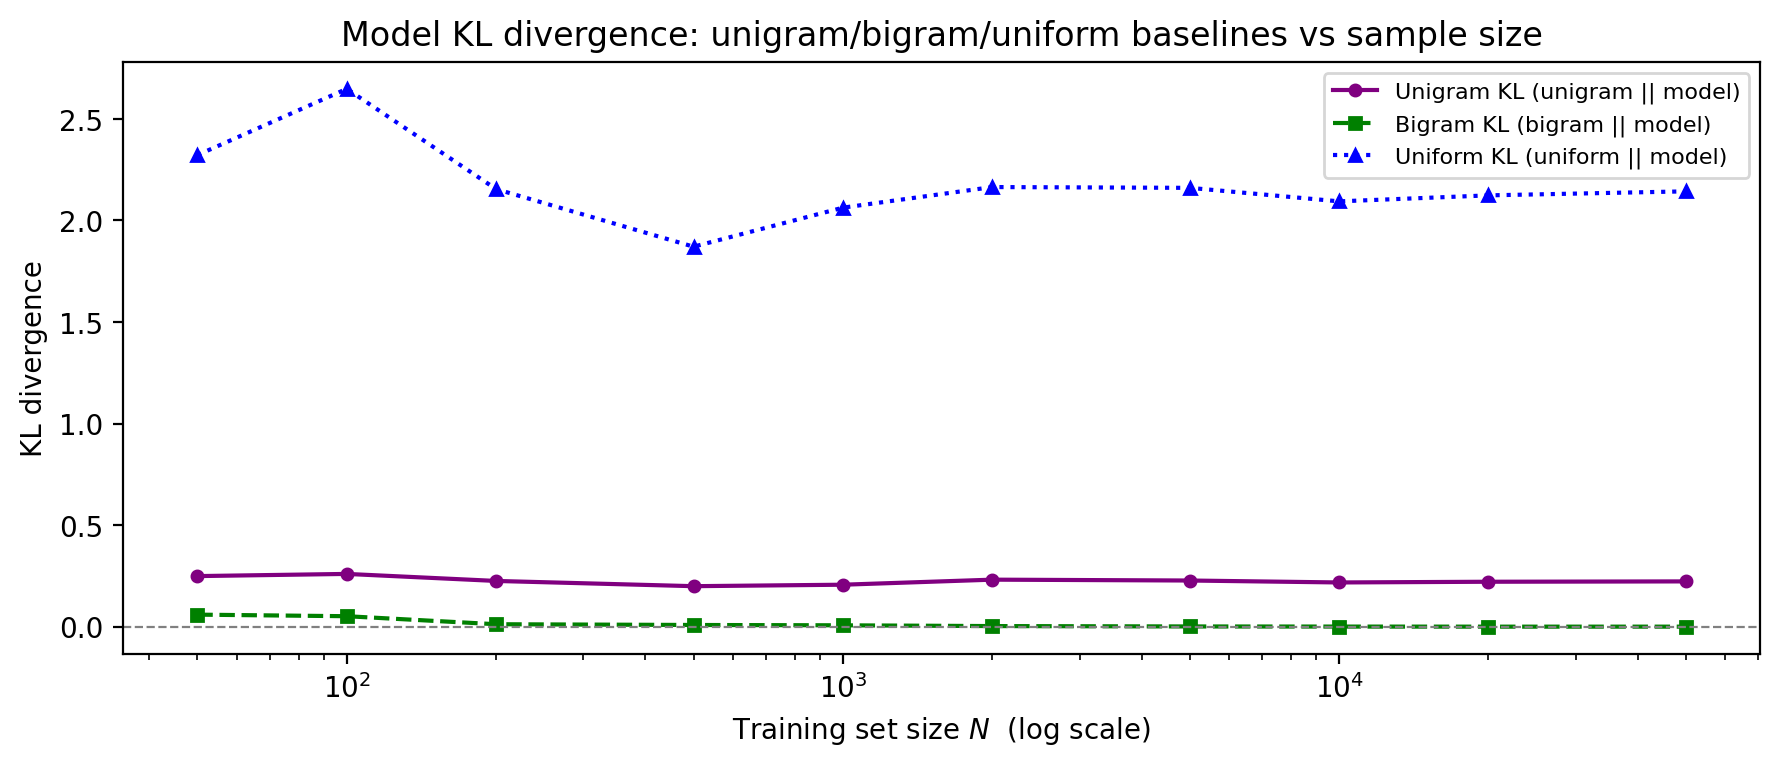

Final unigram KL at max N: 0.223159
Final bigram KL at max N: 0.000420
Final uniform KL at max N: 2.143166


In [6]:
# Extract the new KL values
gen_kl_unigram = [r["gen_kl_unigram"] for r in records]
gen_kl_bigram = [r["gen_kl_bigram"] for r in records]
gen_kl_uniform = [r["gen_kl_uniform"] for r in records]

fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.semilogx(
    Ns,
    gen_kl_unigram,
    label="Unigram KL (unigram || model)",
    color="purple",
    linestyle="-",
    marker="o",
    markersize=4,
)
ax3.semilogx(
    Ns,
    gen_kl_bigram,
    label="Bigram KL (bigram || model)",
    color="green",
    linestyle="--",
    marker="s",
    markersize=4,
)
ax3.semilogx(
    Ns,
    gen_kl_uniform,
    label="Uniform KL (uniform || model)",
    color="blue",
    linestyle=":",
    marker="^",
    markersize=4,
)
ax3.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax3.set_xlabel("Training set size $N$  (log scale)")
ax3.set_ylabel("KL divergence")
ax3.set_title("Model KL divergence: unigram/bigram/uniform baselines vs sample size")
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Final unigram KL at max N: {gen_kl_unigram[-1]:.6f}")
print(f"Final bigram KL at max N: {gen_kl_bigram[-1]:.6f}")
print(f"Final uniform KL at max N: {gen_kl_uniform[-1]:.6f}")

## 2.5 — KL divergence (baseline || model) vs sample size

Similar to the analysis in 05_analysis.ipynb, plot KL(baseline || model) for unigram, bigram, and uniform baselines vs training sample size.

In [7]:
# Extract the new KL values
gen_kl_unigram = [r["gen_kl_unigram"] for r in records]
gen_kl_bigram = [r["gen_kl_bigram"] for r in records]
gen_kl_uniform = [r["gen_kl_uniform"] for r in records]

fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.semilogx(
    Ns,
    gen_kl_unigram,
    label="Unigram KL (unigram || model)",
    color="purple",
    linestyle="-",
    marker="o",
    markersize=4,
)
ax3.semilogx(
    Ns,
    gen_kl_bigram,
    label="Bigram KL (bigram || model)",
    color="green",
    linestyle="--",
    marker="s",
    markersize=4,
)
ax3.semilogx(
    Ns,
    gen_kl_uniform,
    label="Uniform KL (uniform || model)",
    color="blue",
    linestyle=":",
    marker="^",
    markersize=4,
)
ax3.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax3.set_xlabel("Training set size $N$  (log scale)")
ax3.set_ylabel("KL divergence")
ax3.set_title("Model KL divergence: unigram/bigram/uniform baselines vs sample size")
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Final unigram KL at max N: {gen_kl_unigram[-1]:.6f}")
print(f"Final bigram KL at max N: {gen_kl_bigram[-1]:.6f}")
print(f"Final uniform KL at max N: {gen_kl_uniform[-1]:.6f}")

SyntaxError: invalid decimal literal (3127193566.py, line 23)

## 3 — Transition matrix gallery at selected $N$

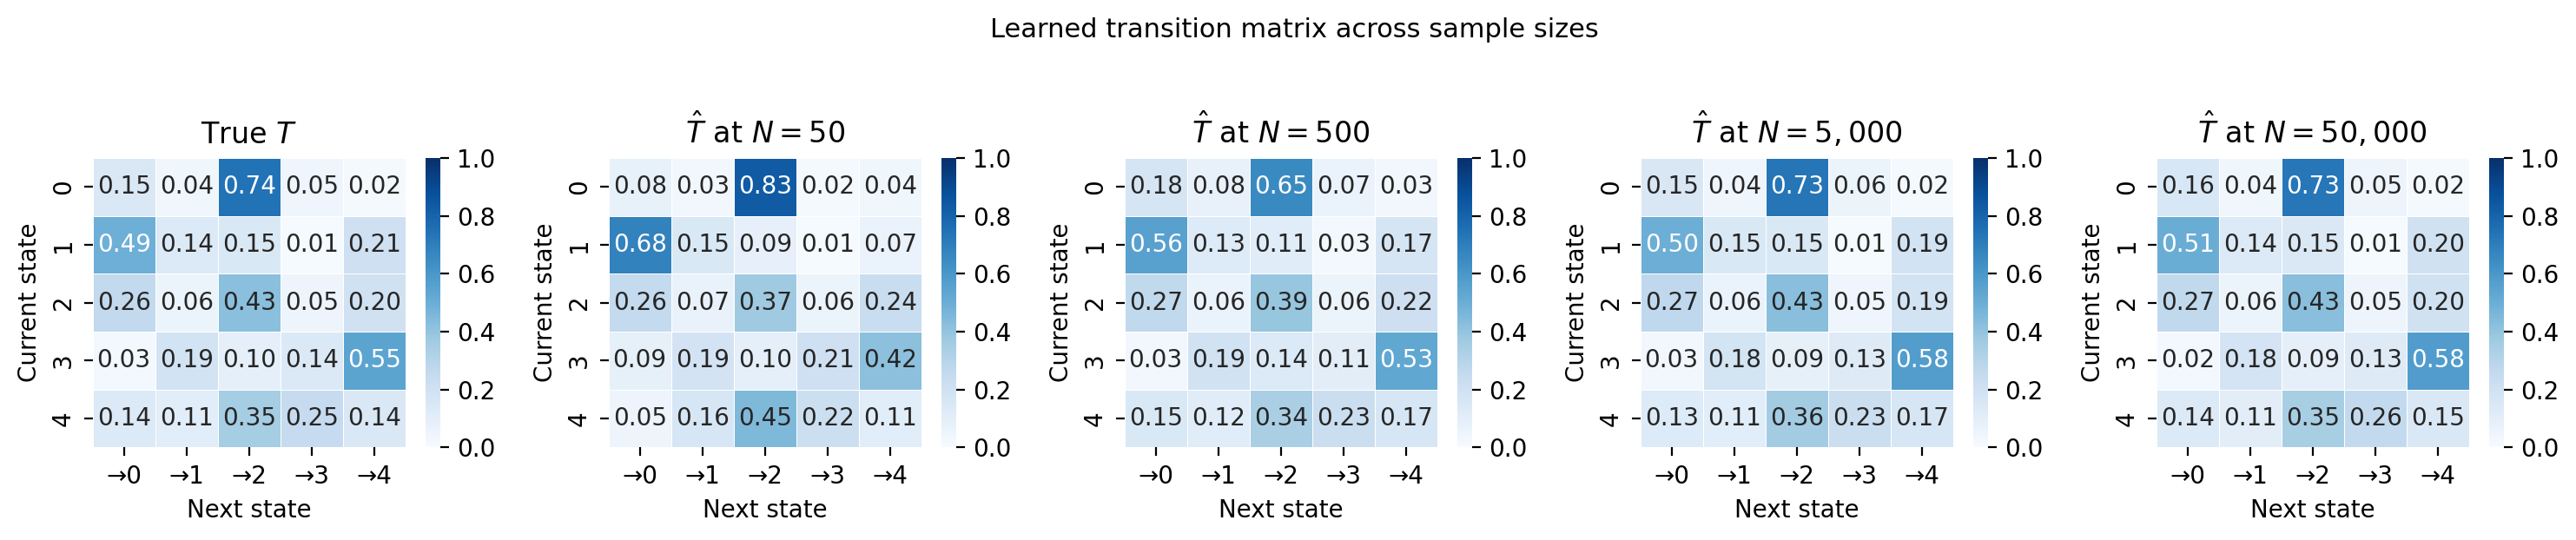

In [9]:
# Show T_true, then T_model at ~4 evenly spaced N values
n_show = min(4, len(records))
indices = np.linspace(0, len(records) - 1, n_show, dtype=int)

ncols = n_show + 1  # +1 for the reference T
fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))

kw = dict(
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    xticklabels=[f"→{j}" for j in range(VOCAB)],
    yticklabels=[str(i) for i in range(VOCAB)],
)

sns.heatmap(T_reference.numpy(), ax=axes[0], **kw)
axes[0].set_title("True $T$")

for col, idx in enumerate(indices, start=1):
    r = records[idx]
    sns.heatmap(r["T_model"], ax=axes[col], **kw)
    axes[col].set_title(f"$\\hat T$ at $N={r['N']:,}$")

for ax in axes:
    ax.set_xlabel("Next state")
    ax.set_ylabel("Current state")

plt.suptitle("Learned transition matrix across sample sizes", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 4 — Per-epoch training dynamics at selected $N$

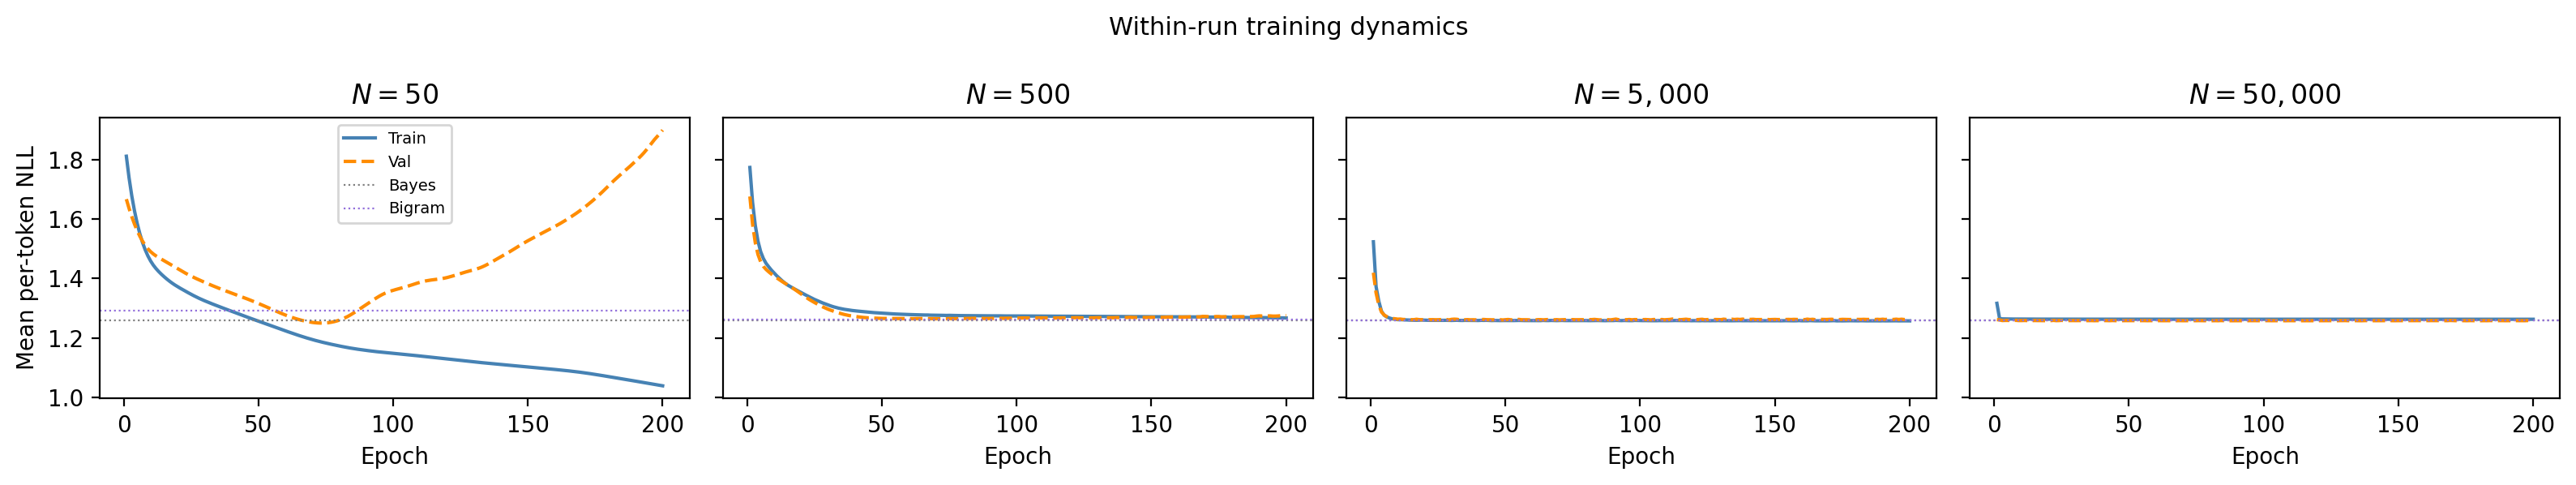

In [10]:
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3), sharey=True)

for ax, idx in zip(axes, indices):
    r = records[idx]
    epochs = range(1, len(r["train_hist"]) + 1)
    ax.plot(epochs, r["train_hist"], color="steelblue", label="Train")
    ax.plot(epochs, r["val_hist"], color="darkorange", linestyle="--", label="Val")
    ax.axhline(bayes_nll, color="gray", linewidth=0.8, linestyle=":", label="Bayes")
    ax.axhline(
        r["nll_bigram"],
        color="mediumpurple",
        linewidth=0.8,
        linestyle=":",
        label="Bigram",
    )
    ax.set_title(f"$N={r['N']:,}$")
    ax.set_xlabel("Epoch")

axes[0].set_ylabel("Mean per-token NLL")
axes[0].legend(fontsize=7)
plt.suptitle("Within-run training dynamics", fontsize=11)
plt.tight_layout()
plt.show()